In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

In [2]:
data = pd.read_csv("Train.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
data = data.drop("ID", axis=1)

In [4]:
label_encoder = LabelEncoder()

categorical_columns = [
    "Warehouse_block",
    "Mode_of_Shipment",
    "Product_importance",
    "Gender"
]

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

In [5]:
data.fillna(data.mean(), inplace=True)

for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

In [6]:
X = data.drop("Reached.on.Time_Y.N", axis=1)
y = data["Reached.on.Time_Y.N"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6668181818181819


In [9]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.6790909090909091


In [10]:
print("\nRandom Forest Report:")
print(classification_report(y_test, rf_pred))

print("\nXGBoost Report:")
print(classification_report(y_test, y_pred))


Random Forest Report:
              precision    recall  f1-score   support

           0       0.57      0.70      0.63       895
           1       0.76      0.64      0.70      1305

    accuracy                           0.67      2200
   macro avg       0.67      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200


XGBoost Report:
              precision    recall  f1-score   support

           0       0.57      0.82      0.68       895
           1       0.83      0.58      0.68      1305

    accuracy                           0.68      2200
   macro avg       0.70      0.70      0.68      2200
weighted avg       0.72      0.68      0.68      2200



In [11]:
cm_rf = confusion_matrix(y_test, rf_pred)
cm_xgb = confusion_matrix(y_test, y_pred)

cm_dict = {
    "Random Forest": cm_rf,
    "XGBoost": cm_xgb
}

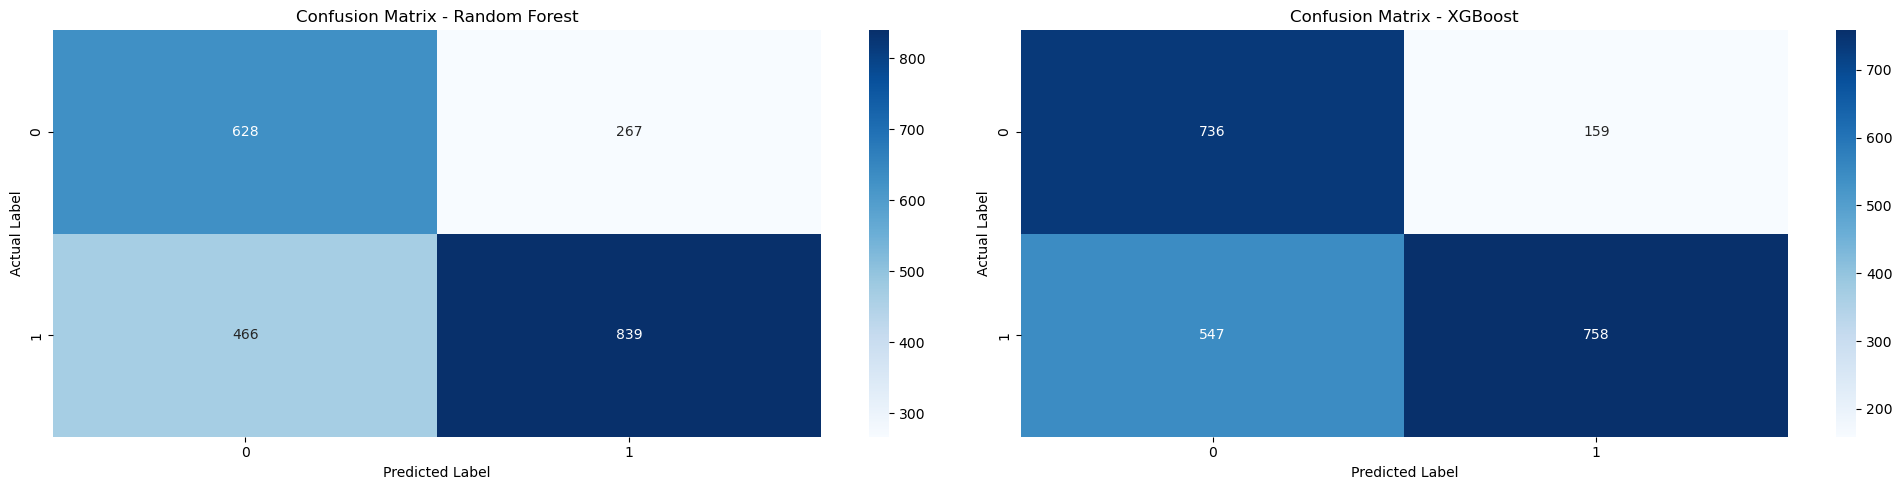

In [12]:
plt.figure(figsize=(20,5))

for index, (model_name, matrix) in enumerate(cm_dict.items(), start=1):
    plt.subplot(1,2,index)
    sns.heatmap(matrix, annot=True, cmap="Blues", fmt="d")
    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

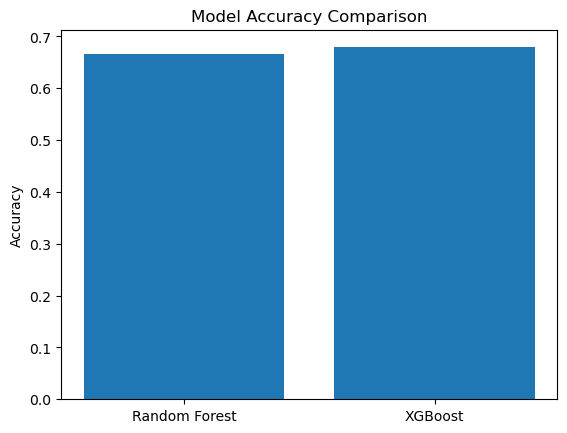

In [13]:
models = ["Random Forest", "XGBoost"]
scores = [rf_accuracy, xgb_accuracy]

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [14]:
import pandas as pd

rf_importance = rf_model.feature_importances_

rf_features = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

print(rf_features)

               Feature  Importance
9        Weight_in_gms    0.297498
8     Discount_offered    0.208433
4  Cost_of_the_Product    0.176517
0      Warehouse_block    0.061332
3      Customer_rating    0.058972
2  Customer_care_calls    0.054839
5      Prior_purchases    0.054295
1     Mode_of_Shipment    0.032969
6   Product_importance    0.031093
7               Gender    0.024052


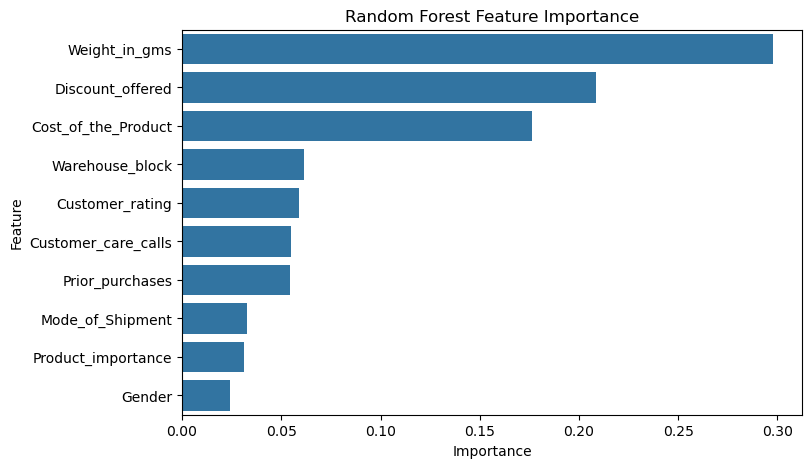

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(x="Importance", y="Feature", data=rf_features)

plt.title("Random Forest Feature Importance")

plt.show()

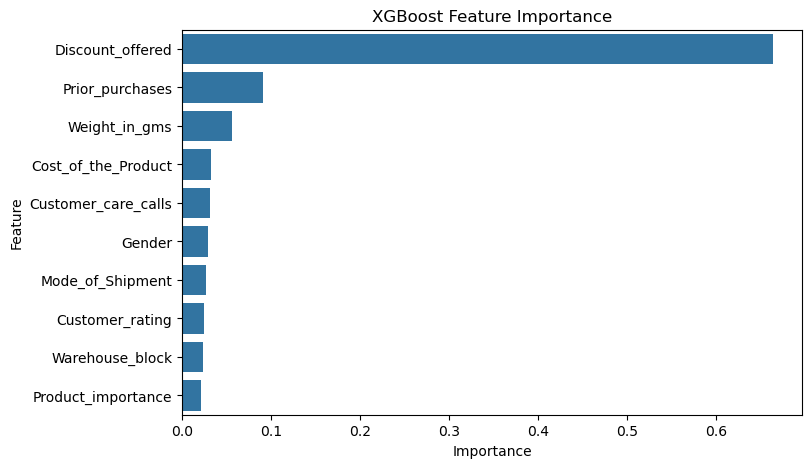

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(x="Importance", y="Feature", data=xgb_features)

plt.title("XGBoost Feature Importance")

plt.show()

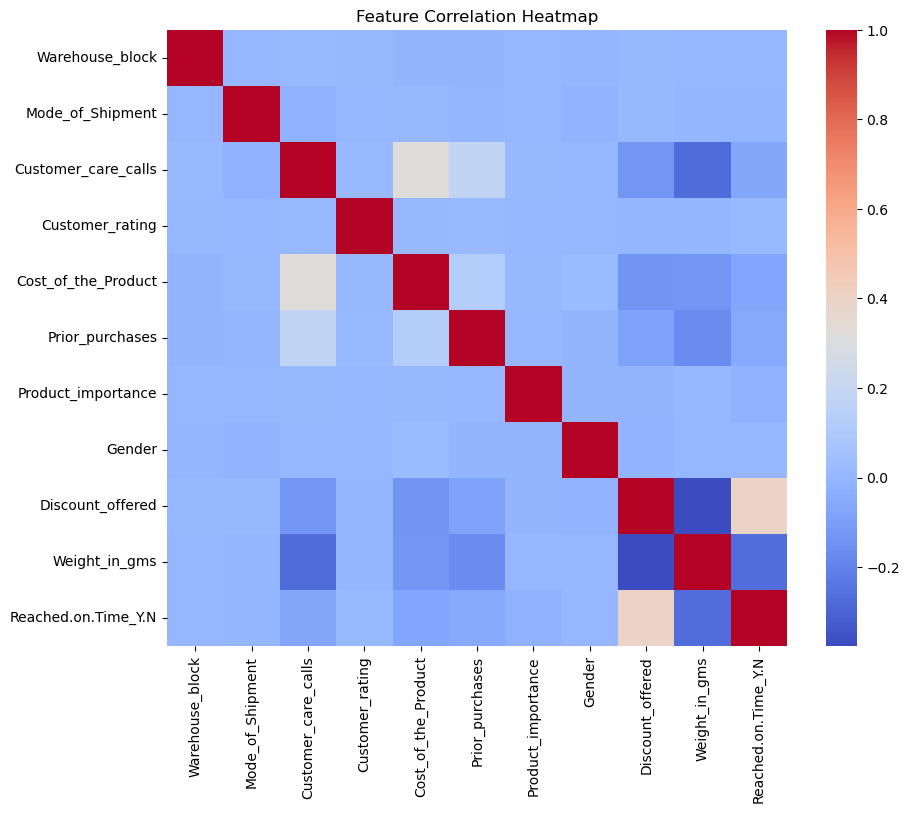

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

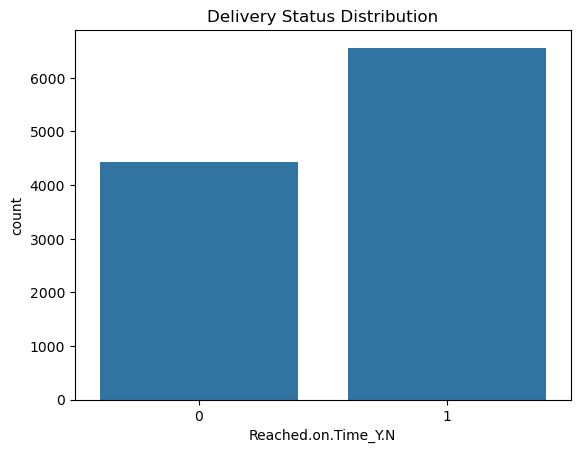

In [19]:
sns.countplot(x="Reached.on.Time_Y.N", data=data)

plt.title("Delivery Status Distribution")

plt.show()

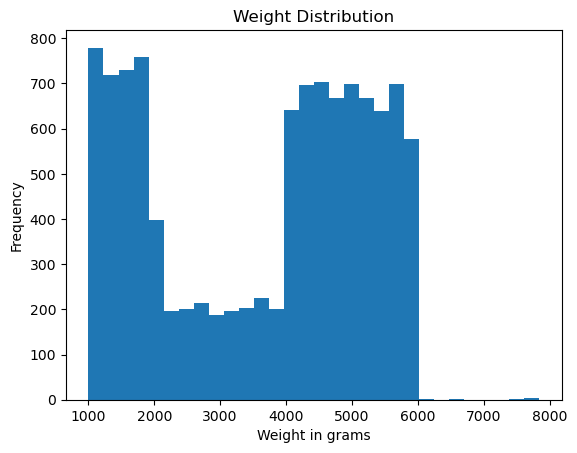

In [21]:
plt.hist(data["Weight_in_gms"], bins=30)

plt.title("Weight Distribution")

plt.xlabel("Weight in grams")
plt.ylabel("Frequency")

plt.show()

In [22]:
comparison = pd.DataFrame({
    "Actual": y_test[:15],
    "Predicted_RF": rf_pred[:15],
    "Predicted_XGB": y_pred[:15]
})

print(comparison)

      Actual  Predicted_RF  Predicted_XGB
107        1             1              1
5594       1             0              0
6997       0             1              0
3984       0             0              0
3111       1             1              1
4040       0             0              0
3013       1             1              1
6606       1             1              1
4219       0             1              1
8749       0             0              0
5664       1             0              0
5369       0             0              0
7495       0             0              0
9885       1             0              0
1851       1             1              1


In [23]:
import pickle

pickle.dump(rf_model, open("random_forest_model.pkl", "wb"))
pickle.dump(xgb_model, open("xgboost_model.pkl", "wb"))

print("Models saved successfully")

Models saved successfully


In [24]:
rf_loaded = pickle.load(open("random_forest_model.pkl", "rb"))
xgb_loaded = pickle.load(open("xgboost_model.pkl", "rb"))

print("Models loaded")

Models loaded


In [25]:
sample = X_test.iloc[0:1]

prediction_rf = rf_loaded.predict(sample)
prediction_xgb = xgb_loaded.predict(sample)

print("Random Forest Prediction:", prediction_rf)
print("XGBoost Prediction:", prediction_xgb)

Random Forest Prediction: [1]
XGBoost Prediction: [1]


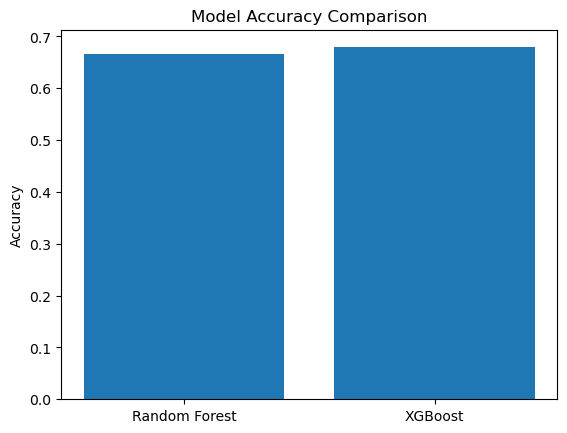

In [26]:
models = ["Random Forest", "XGBoost"]
accuracies = [rf_accuracy, xgb_accuracy]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

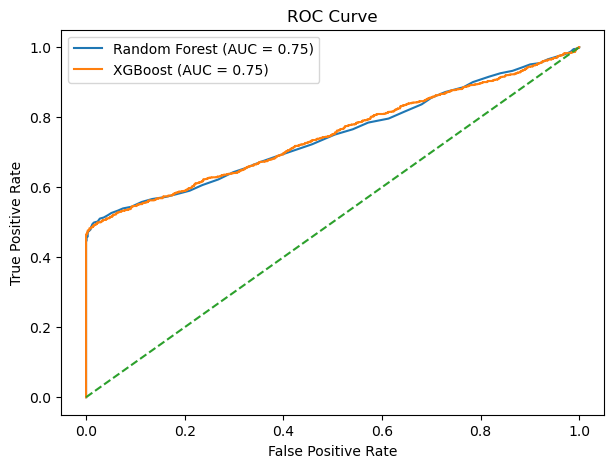

In [27]:
from sklearn.metrics import roc_curve, auc
rf_prob = rf_model.predict_proba(X_test)[:,1]
xgb_prob = xgb_model.predict_proba(X_test)[:,1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# AUC score
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(7,5))

plt.plot(rf_fpr, rf_tpr, label="Random Forest (AUC = %.2f)" % rf_auc)
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost (AUC = %.2f)" % xgb_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

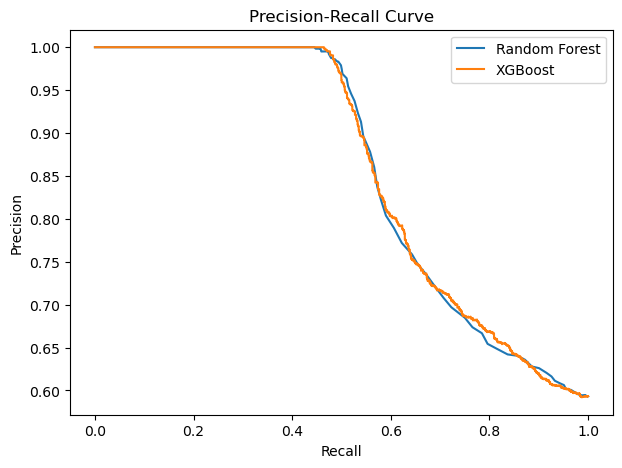

In [28]:
from sklearn.metrics import precision_recall_curve

rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_prob)

plt.figure(figsize=(7,5))

plt.plot(rf_recall, rf_precision, label="Random Forest")
plt.plot(xgb_recall, xgb_precision, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.show()

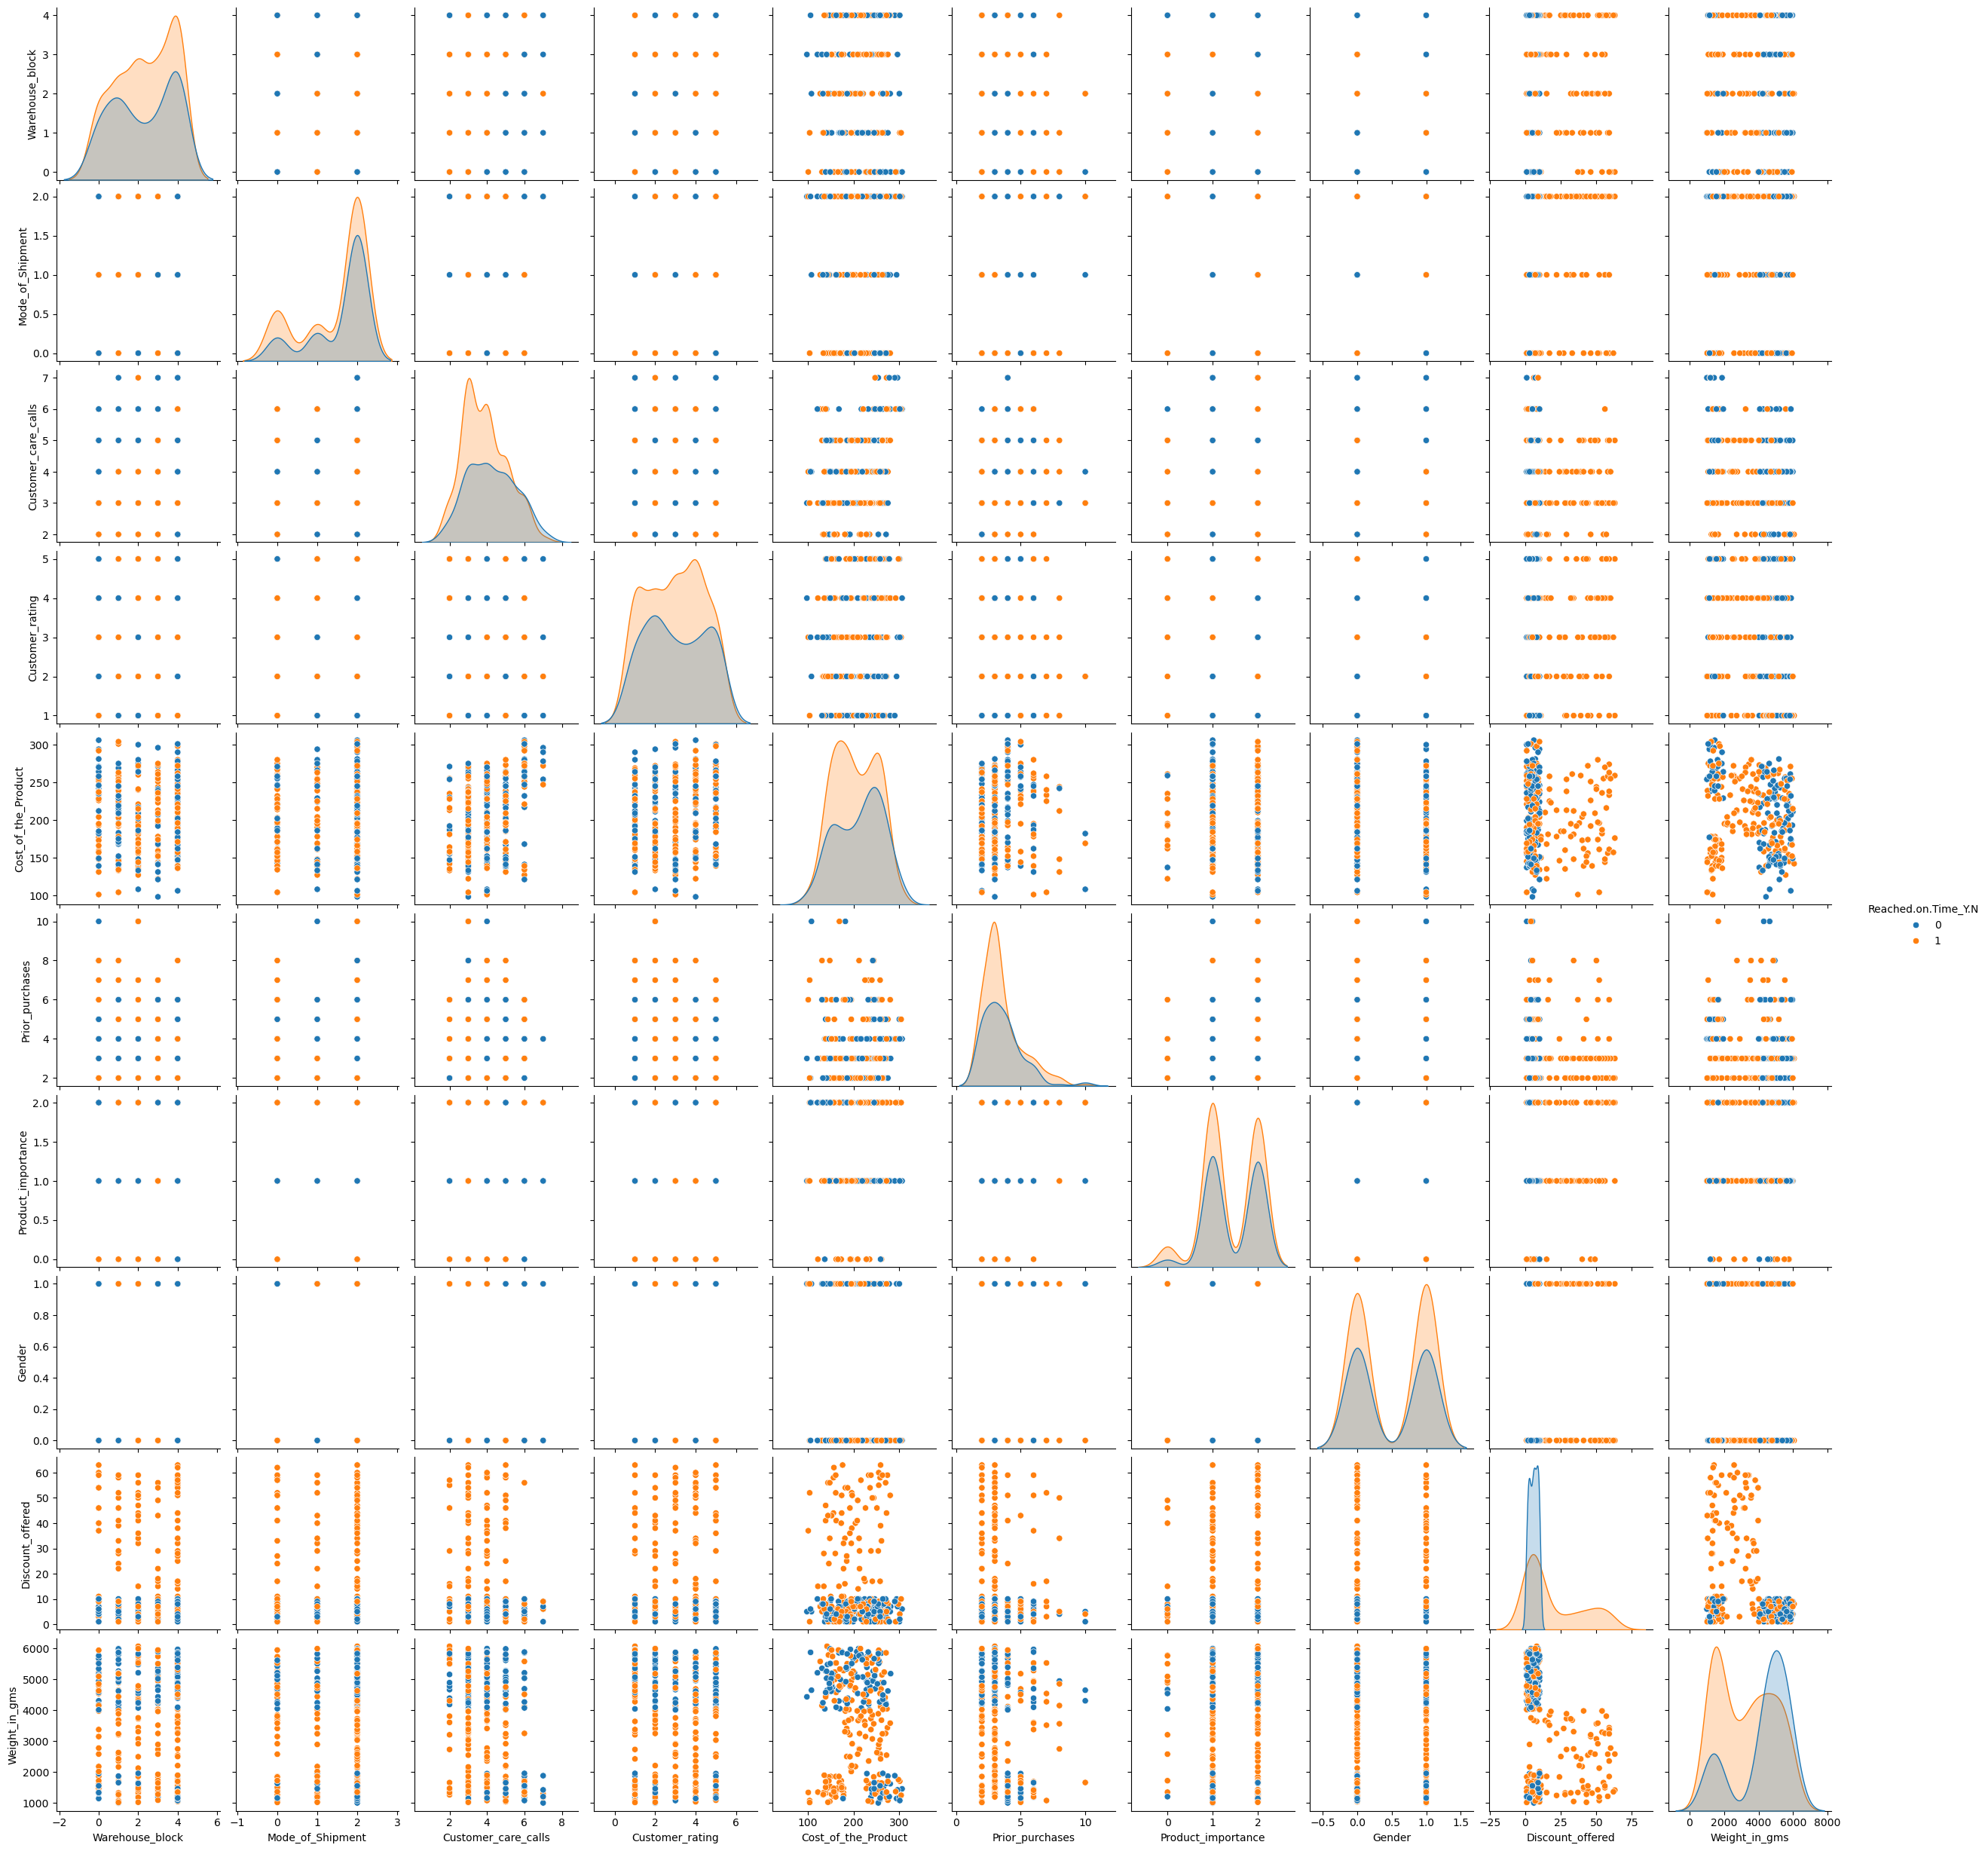

In [29]:
sns.pairplot(data.sample(300), hue="Reached.on.Time_Y.N")

plt.show()

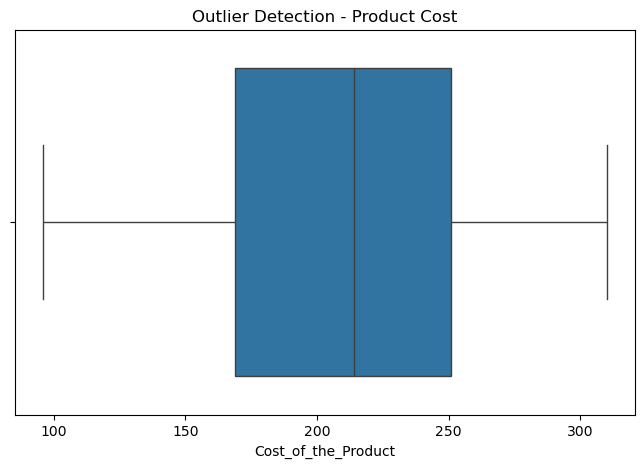

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x=data["Cost_of_the_Product"])

plt.title("Outlier Detection - Product Cost")

plt.show()

In [31]:
metrics = {
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
}

metrics_df = pd.DataFrame(metrics)

print(metrics_df)

           Model  Accuracy
0  Random Forest  0.666818
1        XGBoost  0.679091
